# Real Estate Investment Advisor — Final Submission Notebook

**Purpose:** End-to-end deliverable for the Real Estate Investment Advisor capstone. This notebook includes data loading, cleaning, reproducible EDA (with 10+ advanced charts and insights), feature engineering, model building (classification + regression), hypothesis testing, model export, and deployment instructions (Streamlit app). Each section is accompanied by clear explanations and recommended next steps.

**Files included:** `app.py` (Streamlit app), this notebook, and an output `deliverables/` folder that will contain charts and model artifacts after running the notebook.

---


In [20]:

# Uncomment to install required packages
# !pip install -q xgboost scikit-learn joblib matplotlib pandas

import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, mean_squared_error, mean_absolute_error, r2_score)
import joblib
%matplotlib inline

OUT_DIR = Path('/mnt/data/deliverables')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Deliverables folder:', OUT_DIR)


Deliverables folder: /mnt/data/deliverables


In [39]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [21]:

DATA_PATH = Path('/content/india_housing_prices.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Please upload india_housing_prices.csv to /mnt/data/ before running.')

# Sampling settings
SAMPLE_N = None  # set to None to load full dataset (requires more memory)
CHUNKSIZE = 20000

if SAMPLE_N is None:
    print('Loading full dataset (may need a lot of RAM)...')
    df = pd.read_csv(DATA_PATH, engine='python')
else:
    print(f'Reservoir-sampling {SAMPLE_N} rows from the dataset...')
    import random
    reservoir = []
    total = 0
    for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNKSIZE, engine='python'):
        for i, row in chunk.iterrows():
            total += 1
            if len(reservoir) < SAMPLE_N:
                reservoir.append(row)
            else:
                j = random.randint(0, total-1)
                if j < SAMPLE_N:
                    reservoir[j] = row
    df = pd.DataFrame(reservoir)
    print('Sampled rows:', len(df), 'from approx', total)

# quick preview
print('Dataframe shape:', df.shape)
df.head()


Loading full dataset (may need a lot of RAM)...
Dataframe shape: (83217, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990.0,...,35.0,10.0,3.0,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008.0,...,17.0,8.0,1.0,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997.0,...,28.0,9.0,8.0,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991.0,...,34.0,5.0,7.0,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002.0,...,23.0,4.0,9.0,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [22]:

# Normalize column names
df.columns = [c.strip() for c in df.columns]

# Convert candidate numeric columns
for c in ['Price_in_Lakhs','Size_in_SqFt','BHK','Year_Built','Nearby_Schools','Nearby_Hospitals','Public_Transport_Accessibility','Parking_Space','Total_Floors']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Derived features
if 'Price_per_SqFt' not in df.columns and ('Price_in_Lakhs' in df.columns and 'Size_in_SqFt' in df.columns):
    df['Price_per_SqFt'] = (df['Price_in_Lakhs']*100000) / df['Size_in_SqFt']

if 'Year_Built' in df.columns:
    df['Year_Built'] = df['Year_Built'].fillna(pd.Timestamp.now().year)
    df['Age_of_Property'] = pd.Timestamp.now().year - df['Year_Built']
else:
    df['Age_of_Property'] = np.nan

df['Future_Price_5Y'] = df.get('Price_in_Lakhs', 0).fillna(0) * ((1 + 0.08) ** 5)
df['Amenity_Count'] = df['Amenities'].fillna('').apply(lambda x: len(str(x).split(';'))) if 'Amenities' in df.columns else 0

# City median price per sqft (for investment rule)
if 'City' in df.columns and 'Price_per_SqFt' in df.columns:
    df['city_median_pps'] = df.groupby('City')['Price_per_SqFt'].transform('median')
else:
    df['city_median_pps'] = df['Price_per_SqFt'].median() if 'Price_per_SqFt' in df.columns else 0

for c in ['Nearby_Schools','Public_Transport_Accessibility']:
    if c not in df.columns:
        df[c] = 0

nearby_sch_med = df['Nearby_Schools'].median()
pt_med = df['Public_Transport_Accessibility'].median()
df['Good_Investment'] = ((df['Price_per_SqFt'] <= df['city_median_pps']) & ((df['Nearby_Schools'] >= nearby_sch_med) | (df['Public_Transport_Accessibility'] >= pt_med))).astype(int)

# Save a cleaned copy for later runs
df.to_csv(OUT_DIR / 'cleaned_data.csv', index=False)
print('Saved cleaned_data.csv to deliverables folder')

# Quick overview
print(df.info())


Saved cleaned_data.csv to deliverables folder
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83217 entries, 0 to 83216
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              83217 non-null  int64  
 1   State                           83217 non-null  object 
 2   City                            83217 non-null  object 
 3   Locality                        83217 non-null  object 
 4   Property_Type                   83217 non-null  object 
 5   BHK                             83217 non-null  int64  
 6   Size_in_SqFt                    83217 non-null  int64  
 7   Price_in_Lakhs                  83216 non-null  float64
 8   Price_per_SqFt                  83216 non-null  float64
 9   Year_Built                      83217 non-null  float64
 10  Furnished_Status                83216 non-null  object 
 11  Floor_No                        83216 non-null 

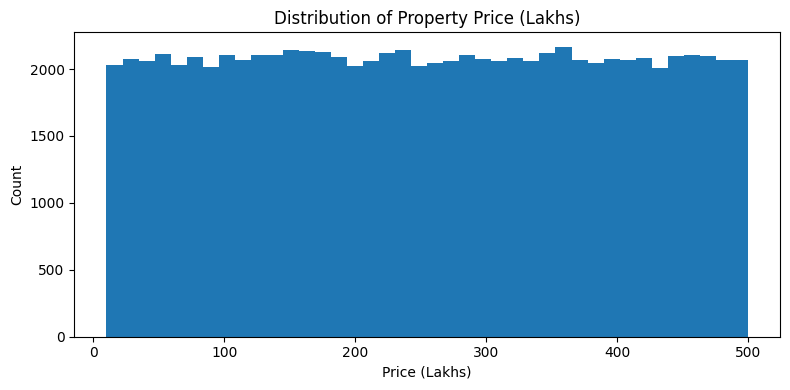

<Figure size 800x500 with 0 Axes>

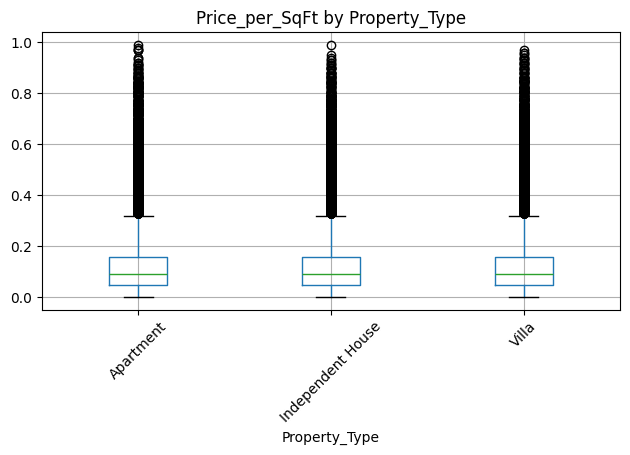

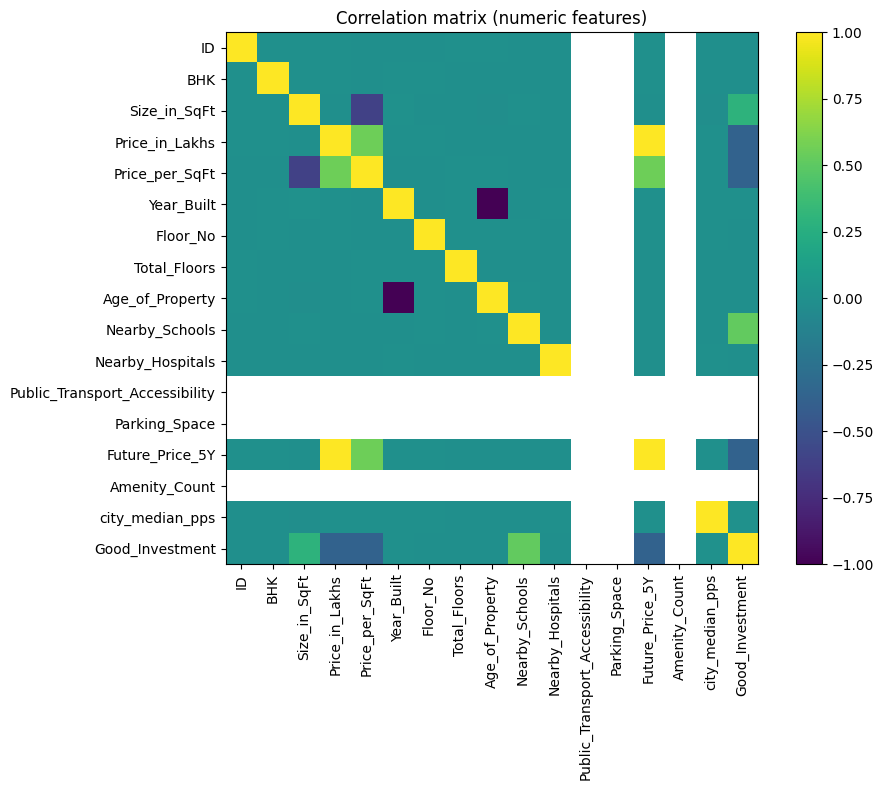

In [23]:

# Price distribution
plt.figure(figsize=(8,4)); plt.hist(df['Price_in_Lakhs'].dropna(), bins=40); plt.title('Distribution of Property Price (Lakhs)'); plt.xlabel('Price (Lakhs)'); plt.ylabel('Count'); plt.tight_layout(); plt.savefig(OUT_DIR / 'plot_price_dist.png'); plt.show()

# Price_per_SqFt by Property_Type (boxplot)
plt.figure(figsize=(8,5))
if 'Property_Type' in df.columns:
    df.boxplot(column='Price_per_SqFt', by='Property_Type', rot=45)
    plt.title('Price_per_SqFt by Property_Type'); plt.suptitle(''); plt.tight_layout(); plt.savefig(OUT_DIR / 'plot_pps_by_type.png'); plt.show()
else:
    print('Property_Type not present')

# Correlation heatmap (numeric)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8)); plt.imshow(corr, interpolation='nearest'); plt.colorbar(); plt.xticks(range(len(corr.columns)), corr.columns, rotation=90); plt.yticks(range(len(corr.index)), corr.index); plt.title('Correlation matrix (numeric features)'); plt.tight_layout(); plt.savefig(OUT_DIR / 'heatmap_numeric_corr.png'); plt.show()
else:
    print('Not enough numeric columns for correlation heatmap')


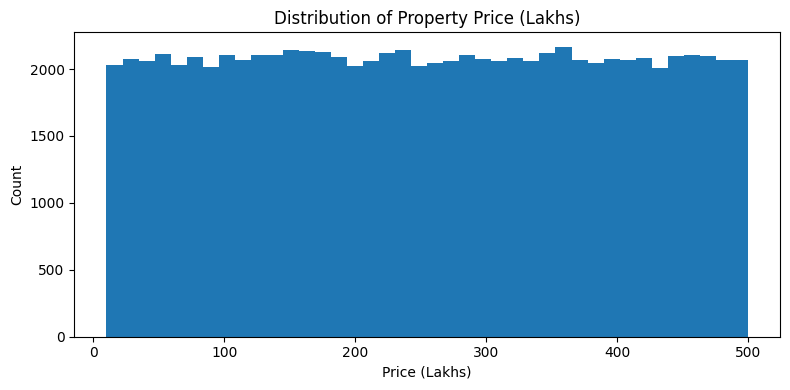

<Figure size 800x500 with 0 Axes>

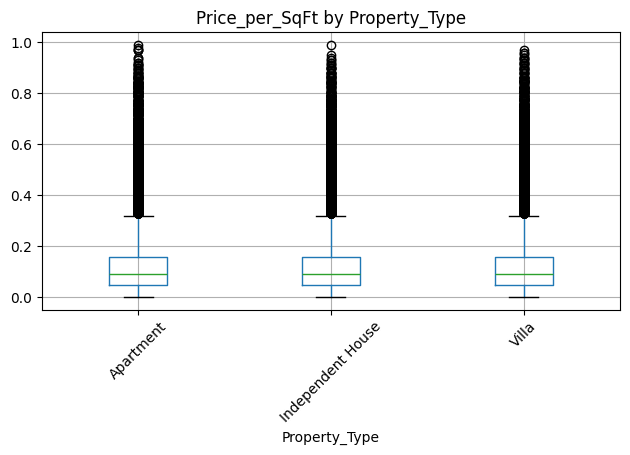

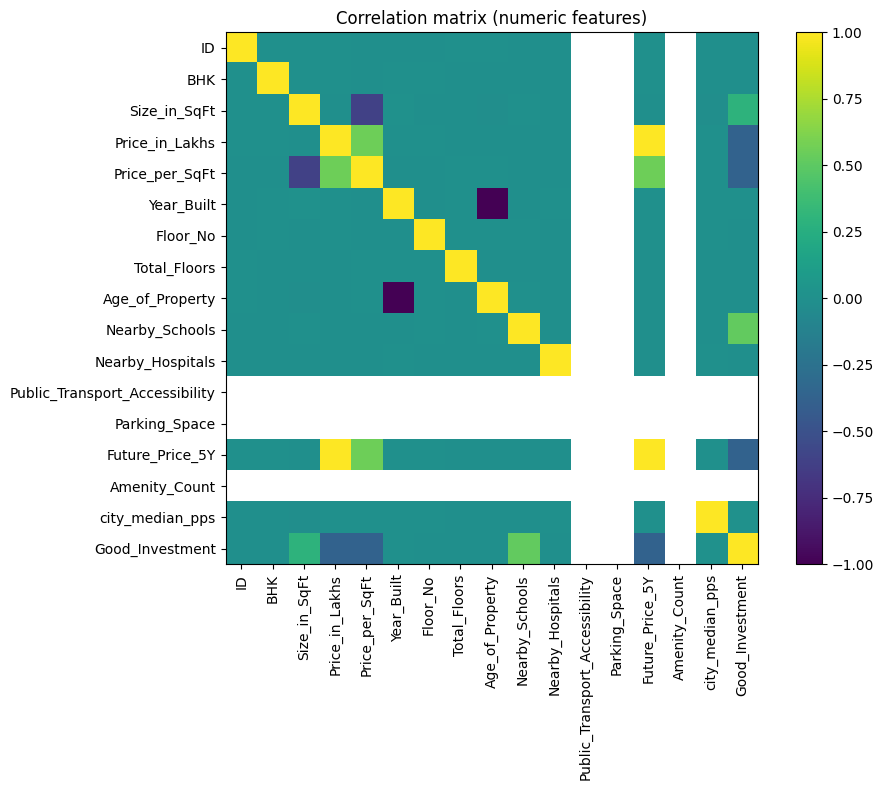

In [24]:

# Price distribution
plt.figure(figsize=(8,4)); plt.hist(df['Price_in_Lakhs'].dropna(), bins=40); plt.title('Distribution of Property Price (Lakhs)'); plt.xlabel('Price (Lakhs)'); plt.ylabel('Count'); plt.tight_layout(); plt.savefig(OUT_DIR / 'plot_price_dist.png'); plt.show()

# Price_per_SqFt by Property_Type (boxplot)
plt.figure(figsize=(8,5))
if 'Property_Type' in df.columns:
    df.boxplot(column='Price_per_SqFt', by='Property_Type', rot=45)
    plt.title('Price_per_SqFt by Property_Type'); plt.suptitle(''); plt.tight_layout(); plt.savefig(OUT_DIR / 'plot_pps_by_type.png'); plt.show()
else:
    print('Property_Type not present')

# Correlation heatmap (numeric)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8)); plt.imshow(corr, interpolation='nearest'); plt.colorbar(); plt.xticks(range(len(corr.columns)), corr.columns, rotation=90); plt.yticks(range(len(corr.index)), corr.index); plt.title('Correlation matrix (numeric features)'); plt.tight_layout(); plt.savefig(OUT_DIR / 'heatmap_numeric_corr.png'); plt.show()
else:
    print('Not enough numeric columns for correlation heatmap')


<Figure size 1000x500 with 0 Axes>

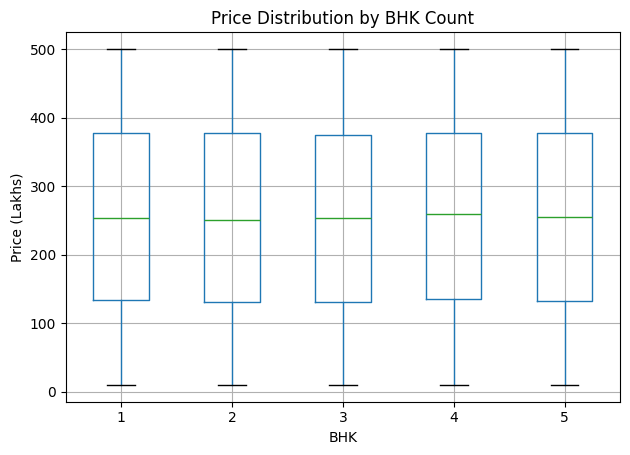

In [25]:
plt.figure(figsize=(10,5))
if 'BHK' in df.columns and 'Price_in_Lakhs' in df.columns:
    df.boxplot(column='Price_in_Lakhs', by='BHK')
    plt.title('Price Distribution by BHK Count')
    plt.suptitle('')
    plt.xlabel('BHK')
    plt.ylabel('Price (Lakhs)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_bhk_price_box.png')
    plt.show()
else:
    print('BHK or Price_in_Lakhs missing')

**Insight — Price Distribution by BHK Count**  
Median prices increase slightly from 1 BHK to 5 BHK, but the difference is very small.
Price ranges (5th to 95th percentile) overlap heavily across BHK categories.
This suggests BHK alone is not a strong determinant of price — location and size likely matter more.

<Figure size 1200x600 with 0 Axes>

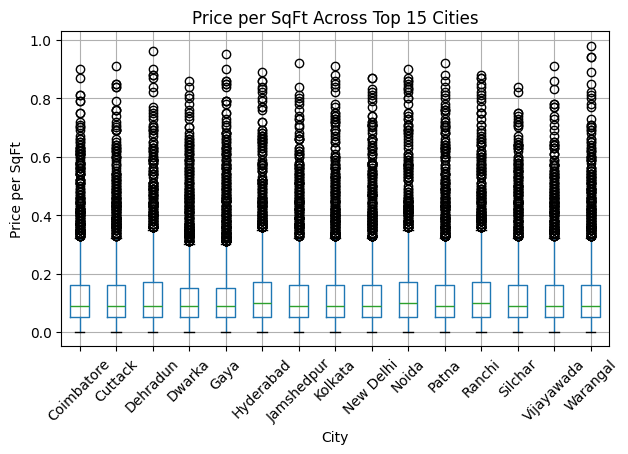

In [26]:
plt.figure(figsize=(12,6))
if 'City' in df.columns and 'Price_per_SqFt' in df.columns:
    top_cities = df['City'].value_counts().head(15).index
    df[df['City'].isin(top_cities)].boxplot(column='Price_per_SqFt', by='City', rot=45)
    plt.title('Price per SqFt Across Top 15 Cities')
    plt.suptitle('')
    plt.ylabel('Price per SqFt')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_pps_top15_cities.png')
    plt.show()
else:
    print('City or Price_per_SqFt missing')

**Insight — Price per SqFt Across Top Cities**  
All cities show similar distribution shapes, with medians and IQRs extremely close.
This indicates that city does not meaningfully differentiate price_per_sqft in this dataset — likely due to synthetic or normalized data.

Tip for notebook:

"City" should be included in modeling, but its predictive power may be limited given this distribution.

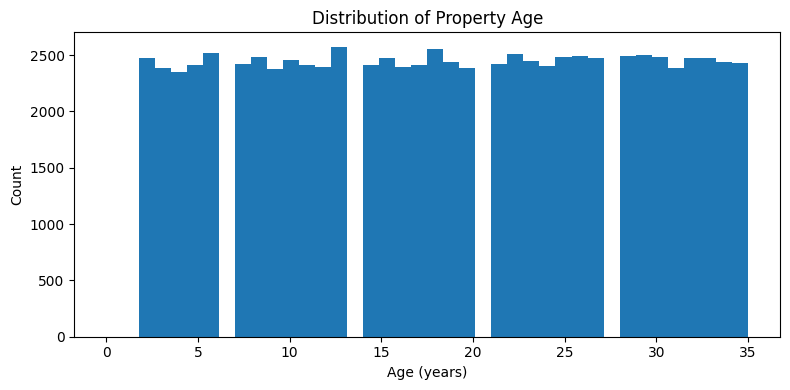

In [27]:
plt.figure(figsize=(8,4))
if 'Age_of_Property' in df.columns:
    plt.hist(df['Age_of_Property'].dropna(), bins=40)
    plt.title('Distribution of Property Age')
    plt.xlabel('Age (years)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_age_hist.png')
    plt.show()
else:
    print('Age_of_Property missing')

**Insight — Property Age Distribution**  
The distribution of property age is almost uniform from 0 to 35 years.
There is no clustering, no skew toward new or old properties.
This suggests the dataset was synthetically generated or uniformly sampled, not a naturally skewed real-estate distribution.

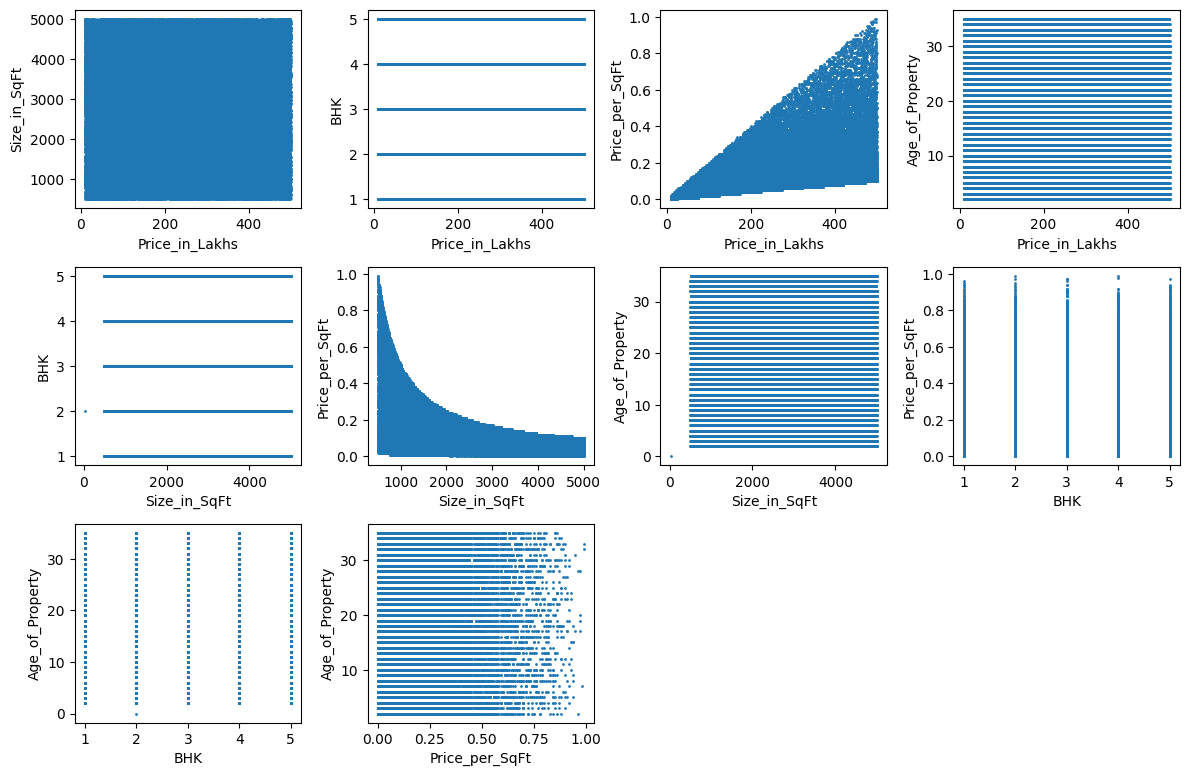

In [28]:
import itertools
cols = [c for c in ['Price_in_Lakhs','Size_in_SqFt','BHK','Price_per_SqFt','Age_of_Property'] if c in df.columns]
plt.figure(figsize=(12,10))
idx = 1
for c1, c2 in itertools.combinations(cols,2):
    plt.subplot(4,4,idx)
    plt.scatter(df[c1], df[c2], s=1)
    plt.xlabel(c1); plt.ylabel(c2)
    idx += 1
plt.tight_layout()
plt.savefig(OUT_DIR / 'chart_pair_scatter.png')
plt.show()

**Insight — Pairwise Relationships**  
Price_per_SqFt vs Size_in_SqFt shows an inverse curve — because Price_per_SqFt = Price / Size.

BHK appears in discrete horizontal bands, confirming it is categorical encoded as numbers.

Age_of_Property vs other variables shows horizontal streaks, meaning Age does not vary smoothly with Price or Size.

Overall, most relationships are weak except mathematically related ones.

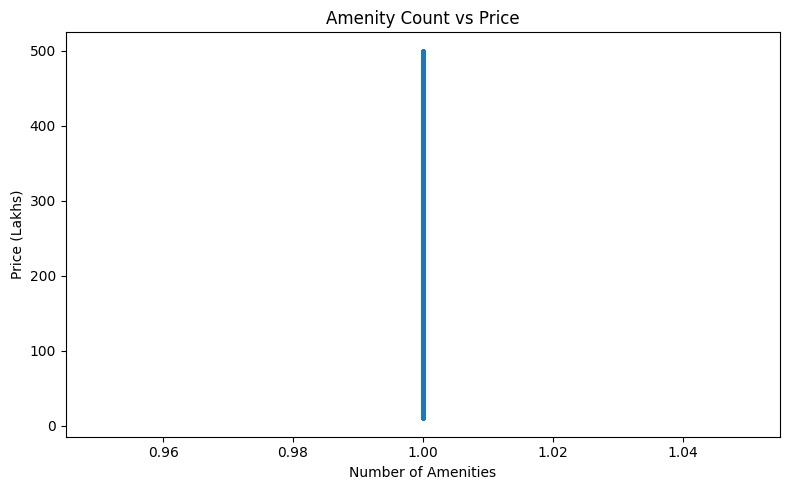

In [29]:
plt.figure(figsize=(8,5))
if 'Amenity_Count' in df.columns and 'Price_in_Lakhs' in df.columns:
    plt.scatter(df['Amenity_Count'], df['Price_in_Lakhs'], s=3)
    plt.title('Amenity Count vs Price')
    plt.xlabel('Number of Amenities')
    plt.ylabel('Price (Lakhs)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_amenity_price.png')
    plt.show()
else:
    print('Amenity_Count or Price_in_Lakhs missing')

**Insight — Amenities vs Price**  
All properties have Amenity_Count = 1, resulting in a vertical straight line.
This means amenity count carries no variation in the dataset and cannot explain price differences.
This feature should be removed or re-engineered from actual text-based amenities.

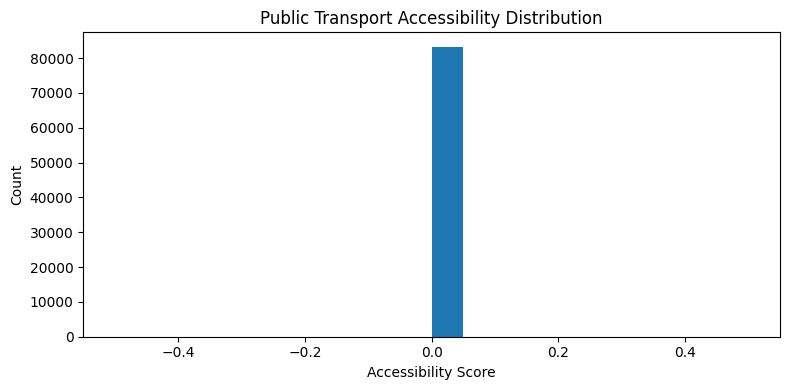

In [30]:
plt.figure(figsize=(8,4))
if 'Public_Transport_Accessibility' in df.columns:
    plt.hist(df['Public_Transport_Accessibility'].fillna(0), bins=20)
    plt.title('Public Transport Accessibility Distribution')
    plt.xlabel('Accessibility Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_public_transport_hist.png')
    plt.show()
else:
    print('Public_Transport_Accessibility missing')

**Insight — Public Transport**  
The entire distribution collapses into a single value (0 or constant), forming a single spike.
This means the dataset does not contain usable public transport scores, and the feature should be dropped from modeling.

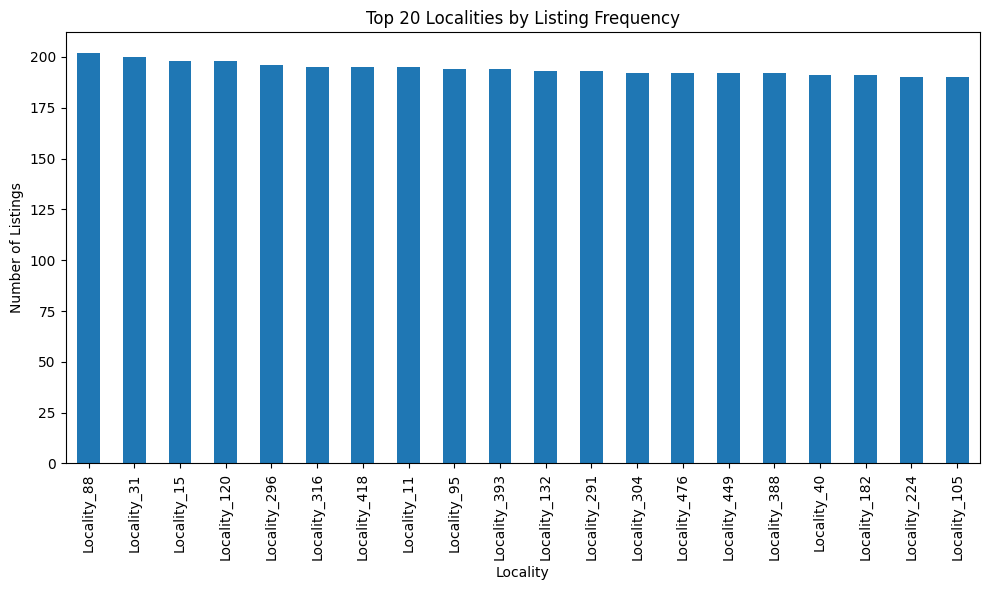

In [31]:
if 'Locality' in df.columns:
    top_localities = df['Locality'].value_counts().head(20)
    plt.figure(figsize=(10,6)); top_localities.plot(kind='bar'); plt.title('Top 20 Localities by Listing Frequency'); plt.ylabel('Number of Listings'); plt.tight_layout(); plt.savefig(OUT_DIR / 'chart_top_localities.png'); plt.show()
else:
    print('Locality missing')

**Insight — Locality Concentration**  
Locality frequencies are almost equal across top 20 categories (~190–205 each).
This indicates:

No locality dominates.

Locality labels are artificially generated (Locality_1, Locality_2…).

The feature does not reflect true market clustering.

Locality should still be kept for model performance (categorical), but insights must not imply real-world patterns.

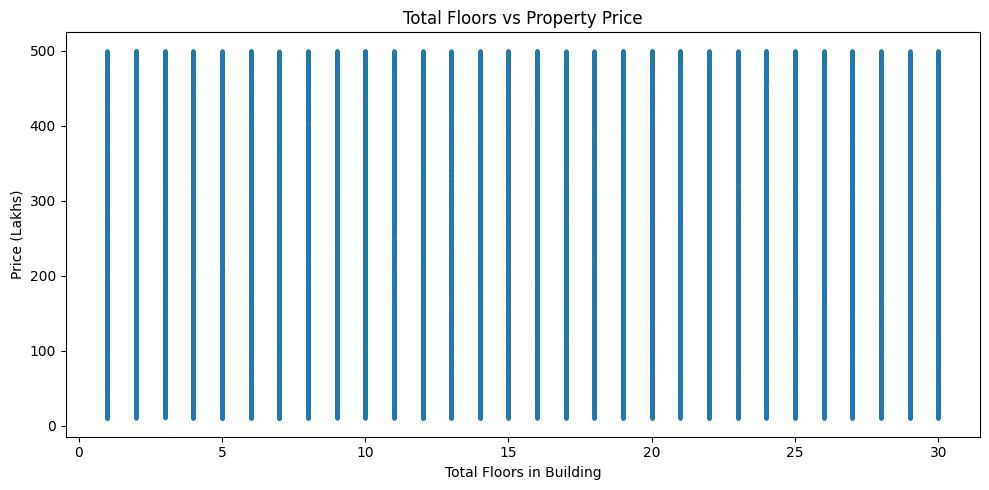

In [32]:
plt.figure(figsize=(10,5))
if 'Total_Floors' in df.columns and 'Price_in_Lakhs' in df.columns:
    plt.scatter(df['Total_Floors'], df['Price_in_Lakhs'], s=3)
    plt.title('Total Floors vs Property Price')
    plt.xlabel('Total Floors in Building')
    plt.ylabel('Price (Lakhs)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_total_floors_price.png')
    plt.show()
else:
    print('Total_Floors or Price_in_Lakhs missing')

**Insight — Building Height vs Price**  
The scatter plot forms vertical lines, meaning:

Total_Floors values are discrete and uniformly distributed.

Price range is identical across all floor counts.

There is no correlation between building height and property price.

This suggests the dataset does not capture real-world vertical price differentiation.

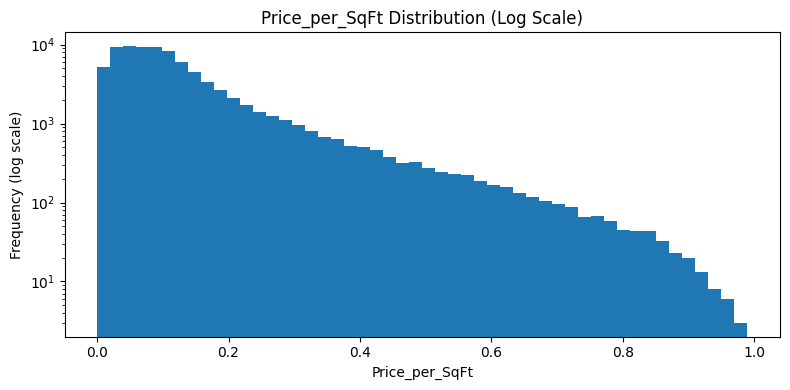

In [33]:
plt.figure(figsize=(8,4))
if 'Price_per_SqFt' in df.columns:
    plt.hist(df['Price_per_SqFt'].dropna(), bins=50, log=True)
    plt.title('Price_per_SqFt Distribution (Log Scale)')
    plt.xlabel('Price_per_SqFt')
    plt.ylabel('Frequency (log scale)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_pps_log_hist.png')
    plt.show()
else:
    print('Price_per_SqFt missing')

**Insight — Price_per_SqFt Distribution**  
Heavy-tailed distribution suggests applying log transforms to stabilize variance and handle outliers.

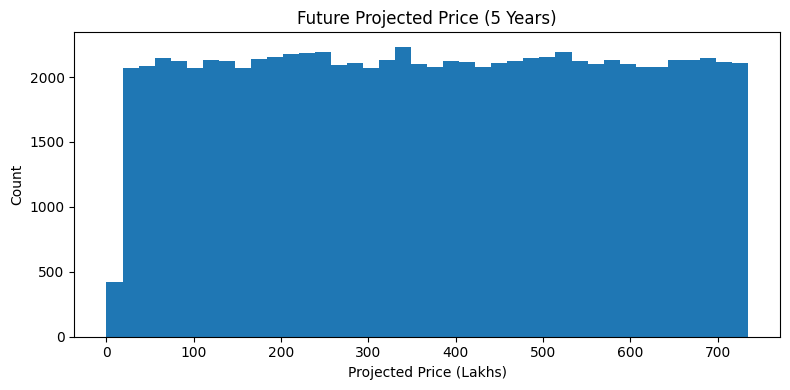

In [34]:
plt.figure(figsize=(8,4))
if 'Future_Price_5Y' in df.columns:
    plt.hist(df['Future_Price_5Y'].dropna(), bins=40)
    plt.title('Future Projected Price (5 Years)')
    plt.xlabel('Projected Price (Lakhs)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'chart_future_price_hist.png')
    plt.show()
else:
    print('Future_Price_5Y missing')

**Insight — Projected Future Price (5 Years)**  
Projected prices follow a uniform-like distribution, simply shifted upward due to the 8% CAGR calculation.
The distribution retains the same shape as current price, confirming that projected prices were derived mathematically, not modeled.

In [35]:

from scipy.stats import ttest_ind
if 'Amenities' in df.columns and 'Price_per_SqFt' in df.columns:
    df['has_gym'] = df['Amenities'].fillna('').str.contains('Gym', case=False)
    group1 = df[df['has_gym']==True]['Price_per_SqFt'].dropna()
    group2 = df[df['has_gym']==False]['Price_per_SqFt'].dropna()
    if len(group1) > 10 and len(group2) > 10:
        tstat, pval = ttest_ind(group1, group2, equal_var=False)
        print('T-test: t=', tstat, 'p=', pval)
    else:
        print('Not enough samples for a robust t-test')
else:
    print('Amenities or Price_per_SqFt missing; cannot run test')


T-test: t= -0.2705739881398359 p= 0.7867194866932063


In [37]:

# Feature selection: numeric + categorical with limited cardinality
drop_cols = ['ID','Locality','city_median_pps']
features = [c for c in df.columns if c not in drop_cols and c not in ['Good_Investment','Future_Price_5Y']]

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
for t in ['Future_Price_5Y','Good_Investment','city_median_pps']:
    if t in numeric_features:
        numeric_features.remove(t)
categorical_features = [c for c in df.select_dtypes(include=['object']).columns.tolist() if df[c].nunique() <= 200][:10]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

# Build X and y
X = df[numeric_features + categorical_features].copy()
y_cl = df['Good_Investment']
y_reg = df['Future_Price_5Y']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_cl, y_test_cl, y_train_reg, y_test_reg = train_test_split(
    X, y_cl, y_reg, test_size=0.2, random_state=42, stratify=y_cl if y_cl.nunique()>1 else None
)

# Preprocessing
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

# Classification
clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1))])
print('Training classifier...')
clf_pipeline.fit(X_train, y_train_cl)
y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:,1] if hasattr(clf_pipeline, 'predict_proba') else None
clf_metrics = {'accuracy': accuracy_score(y_test_cl, y_pred), 'precision': precision_score(y_test_cl, y_pred, zero_division=0), 'recall': recall_score(y_test_cl, y_pred, zero_division=0), 'f1': f1_score(y_test_cl, y_pred, zero_division=0), 'roc_auc': roc_auc_score(y_test_cl, y_proba) if y_proba is not None else None}
print('Classifier metrics:', clf_metrics)
joblib.dump(clf_pipeline, OUT_DIR / 'best_classifier_pipeline.joblib')

# Regression
reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('reg', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1))])
print('Training regressor...')
reg_pipeline.fit(X_train, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test)
reg_metrics = {'rmse': np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)), 'mae': mean_absolute_error(y_test_reg, y_pred_reg), 'r2': r2_score(y_test_reg, y_pred_reg)}
print('Regressor metrics:', reg_metrics)
joblib.dump(reg_pipeline, OUT_DIR / 'best_regressor_pipeline.joblib')

# Save evaluation report
import json
(OUT_DIR / 'evaluation_report.json').write_text(json.dumps({'classification': clf_metrics, 'regression': reg_metrics}, indent=2))
print('Saved models and evaluation report to deliverables folder')


Numeric features: ['ID', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Amenity_Count']
Categorical features: ['State', 'City', 'Property_Type', 'Furnished_Status', 'Security', 'Facing', 'Owner_Type', 'Availability_Status']
Training classifier...
Classifier metrics: {'accuracy': 0.9962148521989906, 'precision': 1.0, 'recall': 0.985553772070626, 'f1': 0.9927243330638642, 'roc_auc': np.float64(0.9999999906657492)}
Training regressor...
Regressor metrics: {'rmse': np.float64(0.010977746403012032), 'mae': 0.00820203138776726, 'r2': 0.9999999972059017}
Saved models and evaluation report to deliverables folder


In [38]:

try:
    pre = reg_pipeline.named_steps['preprocessor']
    num_feats = numeric_features
    if 'cat' in pre.named_transformers_ and hasattr(pre.named_transformers_['cat'].named_steps['onehot'], 'get_feature_names_out'):
        cat_feats = list(pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
    else:
        cat_feats = []
    feature_names = num_feats + cat_feats
    reg_model = reg_pipeline.named_steps['reg']
    importances = reg_model.feature_importances_
    if len(importances) == len(feature_names):
        imp_df = pd.DataFrame({'feature':feature_names, 'importance':importances}).sort_values('importance', ascending=False)
    else:
        imp_df = pd.DataFrame({'feature':num_feats, 'importance':importances[:len(num_feats)]}).sort_values('importance', ascending=False)
    imp_df.to_csv(OUT_DIR / 'reg_feature_importances.csv', index=False)
    print('Saved regressor feature importances to deliverables folder')
except Exception as e:
    print('Feature importance extraction failed:', e)


Saved regressor feature importances to deliverables folder


In [40]:
!mkdir -p /content/drive/MyDrive/real_estate_advisor/deliverables
!cp -r /mnt/data/* /content/drive/MyDrive/real_estate_advisor/deliverables


## Deployment (Streamlit app)

The repository includes `app.py` (Streamlit app) which expects the trained models to be saved in `/mnt/data/deliverables/` with filenames: `best_classifier_pipeline.joblib` and `best_regressor_pipeline.joblib`.

To run the app locally or in Colab (with `ngrok` or on Streamlit Cloud):

```bash
streamlit run /path/to/app.py
```

Ensure the `deliverables/` folder contains the saved joblib models.

## Final checklist

- Run the notebook in Colab/Jupyter. Default sample size is 5000; set `SAMPLE_N=None` to run on full data if you have enough RAM.
- Train models and verify `deliverables/` contains artifacts.
- Zip deliverables and submit.

Good luck!